# Post mofa-flex analysis

### Contents:

1. [Load models (Normal, SnS, and GP).](#load-models)

2. [MOFA-Flex model result overview.](#mofa-flex-results-overview)
<br>
2.1 [Factor correlation and variance explained.](#1-variance-explained)
<br>
2.2 [Average R2.](#2-average-r2)
<br>
2.3 [Weights distribution.](#3weights-dist)
<br>
2.4 [Heatmap (view x LR).](#4-heatmap-view-x-lr)

3. [DR and clustering.](#dr-using-factors-values)

4. [Regression Model.](#regression-model)
<br>
4.1 [Evaluate model.](#evaluate-the-model)
<br>
4.2 [AUC.](#auc)

5. [Map clusters to spatial.](#map-clusters-to-spatial)

In [1]:
import os.path
import anndata as ad
import mudata as md
import numpy as np
import pandas as pd
import mofaflex as mfl
from plotnine import *
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from umap import UMAP
from sklearn.manifold import TSNE

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



# Run MOFA

## Read mdata

In [2]:
mdata_path = Path("/g/stegle/aalsayah/repos/data/merfish/mouse_brain/mudata")

In [3]:
mdata = md.read(mdata_path / "WB_MERFISH_animal2_coronal_mudata.h5mu")

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


In [5]:
mdata

MuData object with n_obs × n_vars = 11904 × 514
  var:	'n_cells'
  20 modalities
    neuroblast_sensu_Vertebrata:	29 x 12
      obs:	'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes'
      var:	'n_cells'
      uns:	'cell_type_colors', 'citation', 'global_score', 'log1p', 'moranI', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
      obsm:	'X_CCF', 'X_spatial_coords', 'X_umap'
      obsp:	'spatial_connectivities'
    ependymal_cell:	31 x 15
      obs:	'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes'
      var:	'n_cells'
      uns:	'cell_type_colors', 'citation', 'global_score', 'log1p', 'moranI', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
      obsm:	'X_CCF', 'X_spatial_coords', 'X_umap'
      obsp:	'spatial_connectivities'
    endothelial_cell:	243 x 55
      obs:	'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes'
      var:	'n_cells'
      uns:	'cell_type_colors', 'citation', 'global_score', 'log1p', 'moranI', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
      obsm:	'X_CCF', 'X_spatial_coords', 'X_umap'
      obsp:	'spatial_connectivities'
    astrocyte:	312 x 63
      obs:	'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes'
      var:	'n_cells'
      uns:	'cell_type_colors', 'citation', 'global_score', 'log1p', 'moranI', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
      obsm:	'X_CCF', 'X_spatial_coords', 'X_umap'
      obsp:	'spatial_connectivities'
    oligodendrocyte:	186 x 52
      obs:	'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_

In [6]:
del mdata.mod["glycinergic_neuron"]
del mdata.mod["monocyte"]
# del mdata.mod["histaminergic_neuron"]
del mdata.mod["dopaminergic_neuron"]
del mdata.mod["dendritic_cell"]
#del mdata.mod["cholinergic_neuron"]
del mdata.mod["macrophage"]
del mdata.mod["lymphocyte"]
# del mdata.mod["smooth_muscle_cell"]
del mdata.mod["pericyte"]
del mdata.mod["tanycyte"]

In [7]:
import mudata as mu
mdata_new = mu.MuData({mod: ad for mod, ad in mdata.mod.items()})

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


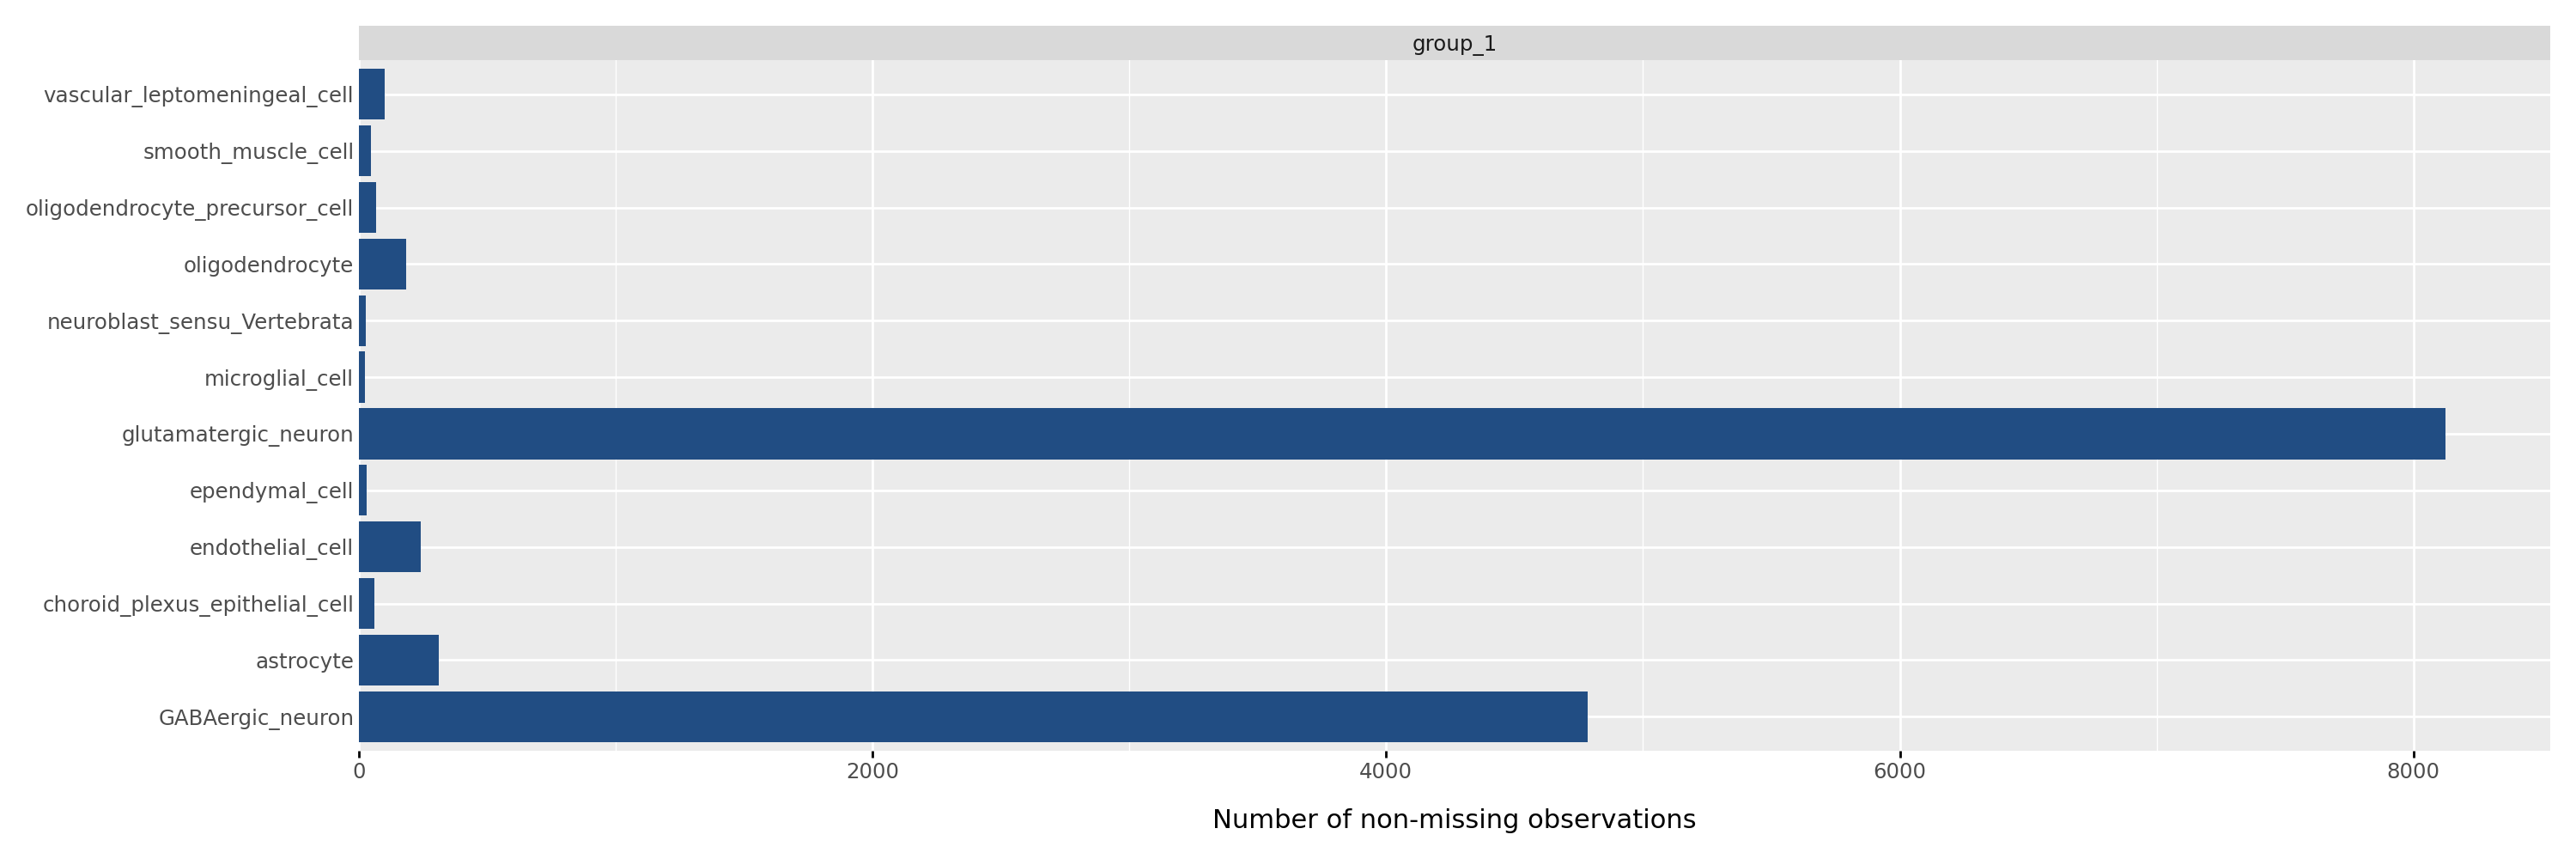

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default any

  0%|                                                                      | 0/1000 [00:00<?, ?epochs/s]

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
INFO	Saving results to /g/stegle/aalsayah/repos/data/merfish/mouse_brain/mofa_models/WB_MERFISH_animal2_coronal_SnS_normal_weight.hdf5...


In [9]:
model = mfl.MOFAFLEX(
    mdata_new,
 #   mfl.DataOptions(covariates_obsm_key="X_spatial_coords"),
    mfl.ModelOptions(
        n_factors=10,
        factor_prior="SnS",
        likelihoods="Normal",
        weight_prior="Normal",
#        nonnegative_factors=True,
#        nonnegative_weights=True
    ),
    mfl.TrainingOptions(
        batch_size=2000,
        n_particles=10,
        lr=0.005,
        max_epochs=1000,
        save_path=str("/g/stegle/aalsayah/repos/data/merfish/mouse_brain/mofa_models/WB_MERFISH_animal2_coronal_SnS_normal_weight.hdf5"),
        early_stopper_patience=50,
    ),
)

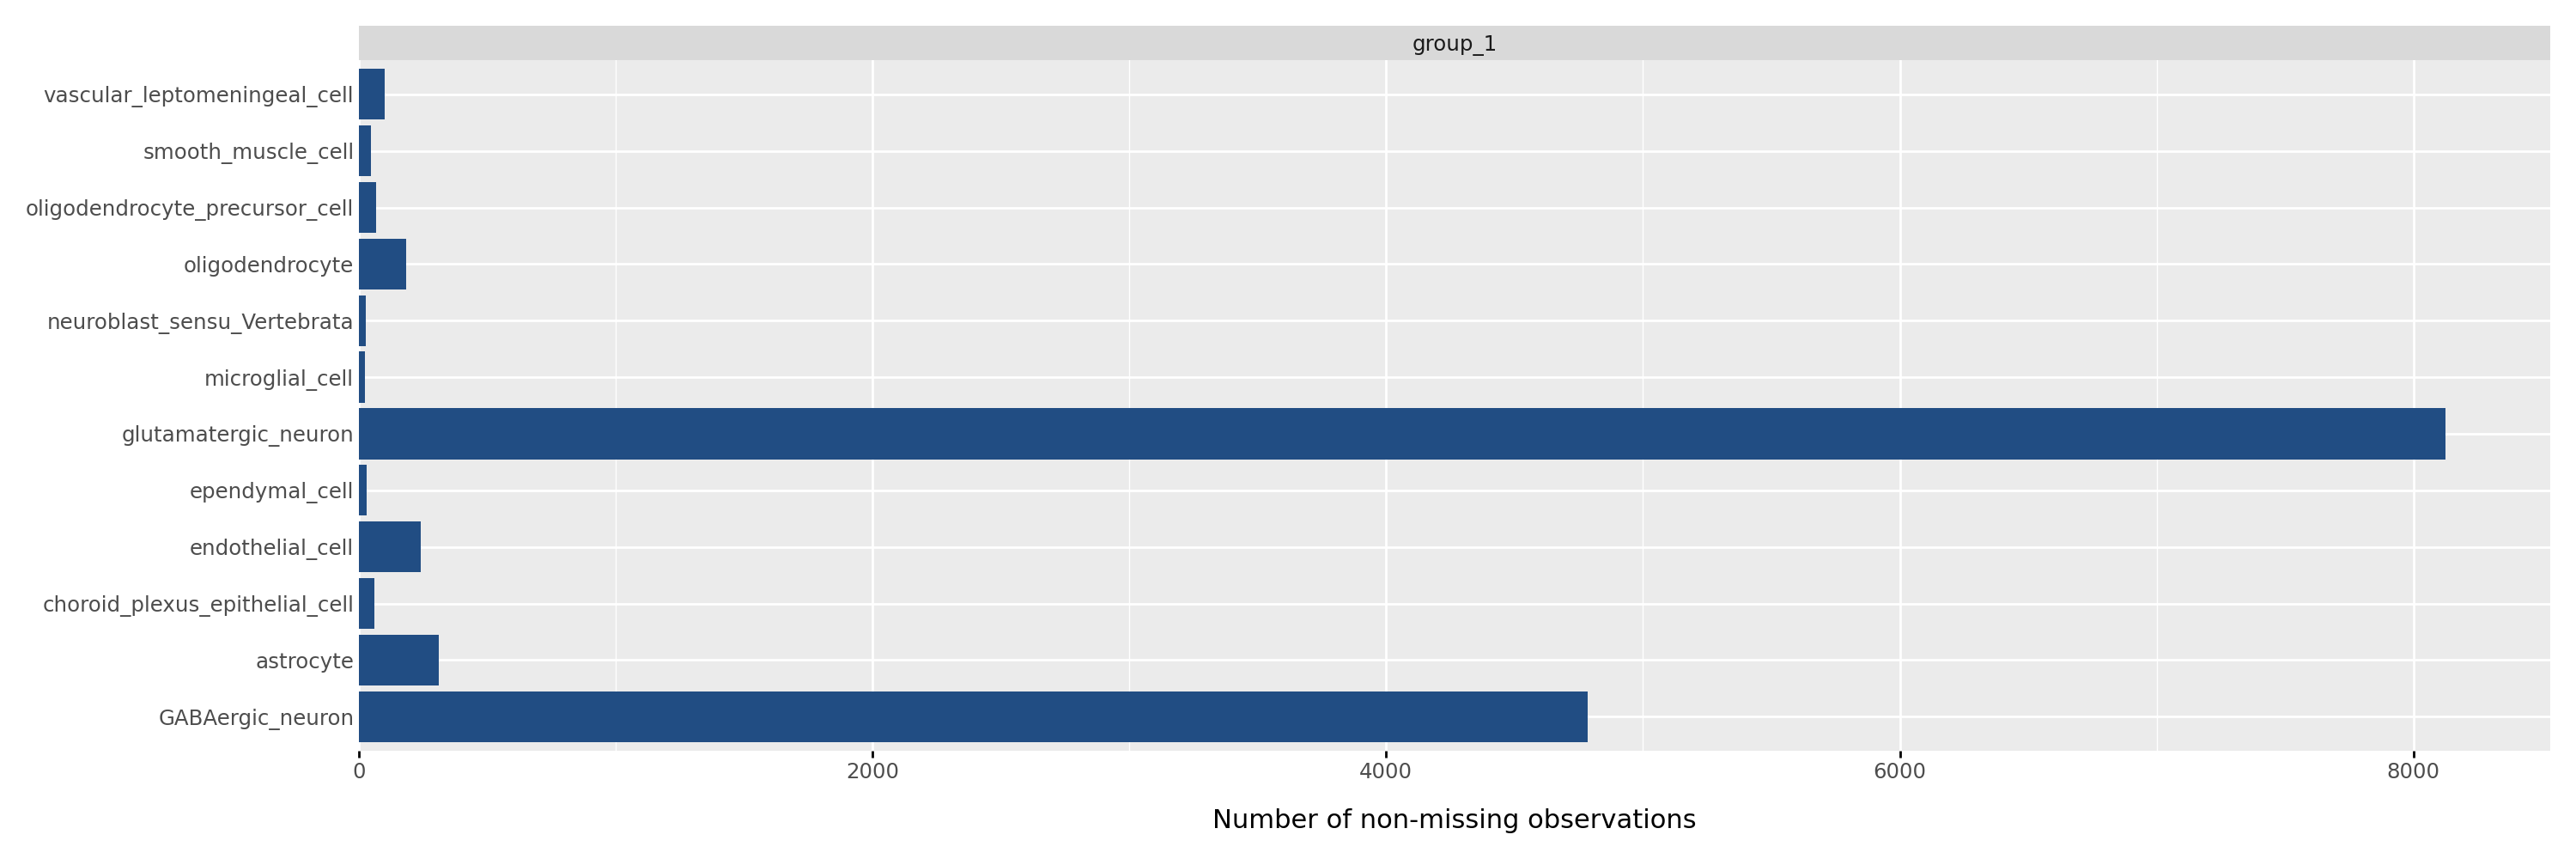

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default any

  0%|                                                                                                         …

In [ ]:
model = mfl.MOFAFLEX(
    mdata_new,
 #   mfl.DataOptions(covariates_obsm_key="X_spatial_coords"),
    mfl.ModelOptions(
        n_factors=10,
        factor_prior="Normal",
        likelihoods="Normal",
        weight_prior="Normal",
        nonnegative_factors=True,
        nonnegative_weights=True
    ),
    mfl.TrainingOptions(
        batch_size=2000,
        n_particles=10,
        lr=0.005,
        max_epochs=1000,
        save_path=str("/g/stegle/aalsayah/repos/data/merfish/mouse_brain/mofa_models/WB_MERFISH_animal2_coronal_nonneg.hdf5"),
        early_stopper_patience=50,
    ),
)

# Load models

In [21]:
models_path = Path("/g/stegle/aalsayah/repos/data/merfish/mouse_brain/mofa_models")

In [22]:
model= mfl.MOFAFLEX.load(models_path / "WB_MERFISH_animal2_coronal_Normal.hdf5")

In [81]:
from plotnine.ggplot import ggplot  # to check object type

def evaluate_single_mofa_model(model, output_dir=None, group="group_1", show_plots=True):
    """
    Evaluate a single trained MOFAFLEX model.
    Handles both plotnine (ggplot) and matplotlib plots.
    """
    if output_dir:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

    results = {}

    # --- Factor correlation ---
    print("Plotting factor correlation...")
    fig1 = mfl.pl.factor_correlation(model)
    if output_dir:
        fc_path = output_dir / "factor_correlation.png"
        if isinstance(fig1, ggplot):
            fig1.save(fc_path, dpi=300)
        else:
            fig1.savefig(fc_path, bbox_inches="tight")
        results["factor_correlation_path"] = str(fc_path)
    if show_plots:
        print(fig1)
    else:
        plt.close('all')

    # # --- quality control for SnS priors ---
    # print("Plotting weight_sparsity_histogram (QC for SnS priors)...")
    # fig1 = mfl.pl.weight_sparsity_histogram(model)
    # if output_dir:
    #     fc_path = output_dir / "weight_sparsity_histogram.png"
    #     if isinstance(fig1, ggplot):
    #         fig1.save(fc_path, dpi=300)
    #     else:
    #         fig1.savefig(fc_path, bbox_inches="tight")
    #     results["weight_sparsity_histogram_path"] = str(fc_path)
    # if show_plots:
    #     print(fig1)
    # else:
    #     plt.close('all')

    # --- Variance explained ---
    print("Plotting variance explained...")
    fig2 = mfl.pl.variance_explained(model, figsize=(8, 8))
    if output_dir:
        ve_path = output_dir / "variance_explained.png"
        if isinstance(fig2, ggplot):
            fig2.save(ve_path, dpi=300)
        else:
            fig2.savefig(ve_path, bbox_inches="tight")
        results["variance_explained_path"] = str(ve_path)
    if show_plots:
        print(fig2)
    else:
        plt.close('all')

    # --- Compute R² ---
    print("Computing R²...")
    r2 = model.get_r2(total=True)
    mean_r2 = float(r2[group].mean())
    results["mean_r2"] = mean_r2
    print(f"✅ Mean R² for {group}: {mean_r2:.4f}")

    # --- Save metrics file ---
    if output_dir:
        metrics_path = output_dir / "metrics.txt"
        with open(metrics_path, "w") as f:
            f.write(f"Mean R² ({group}): {mean_r2:.4f}\n")
        results["metrics_path"] = str(metrics_path)

    return results


Plotting factor correlation...


/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 8 x 8 in image.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /g/stegle/aalsayah/repos/data/merfish/mouse_brain/mofa_models/evaluation_results2/factor_correlation.png
/scratch/jobs/43257208/ipykernel_150798/1526382549.py:25: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


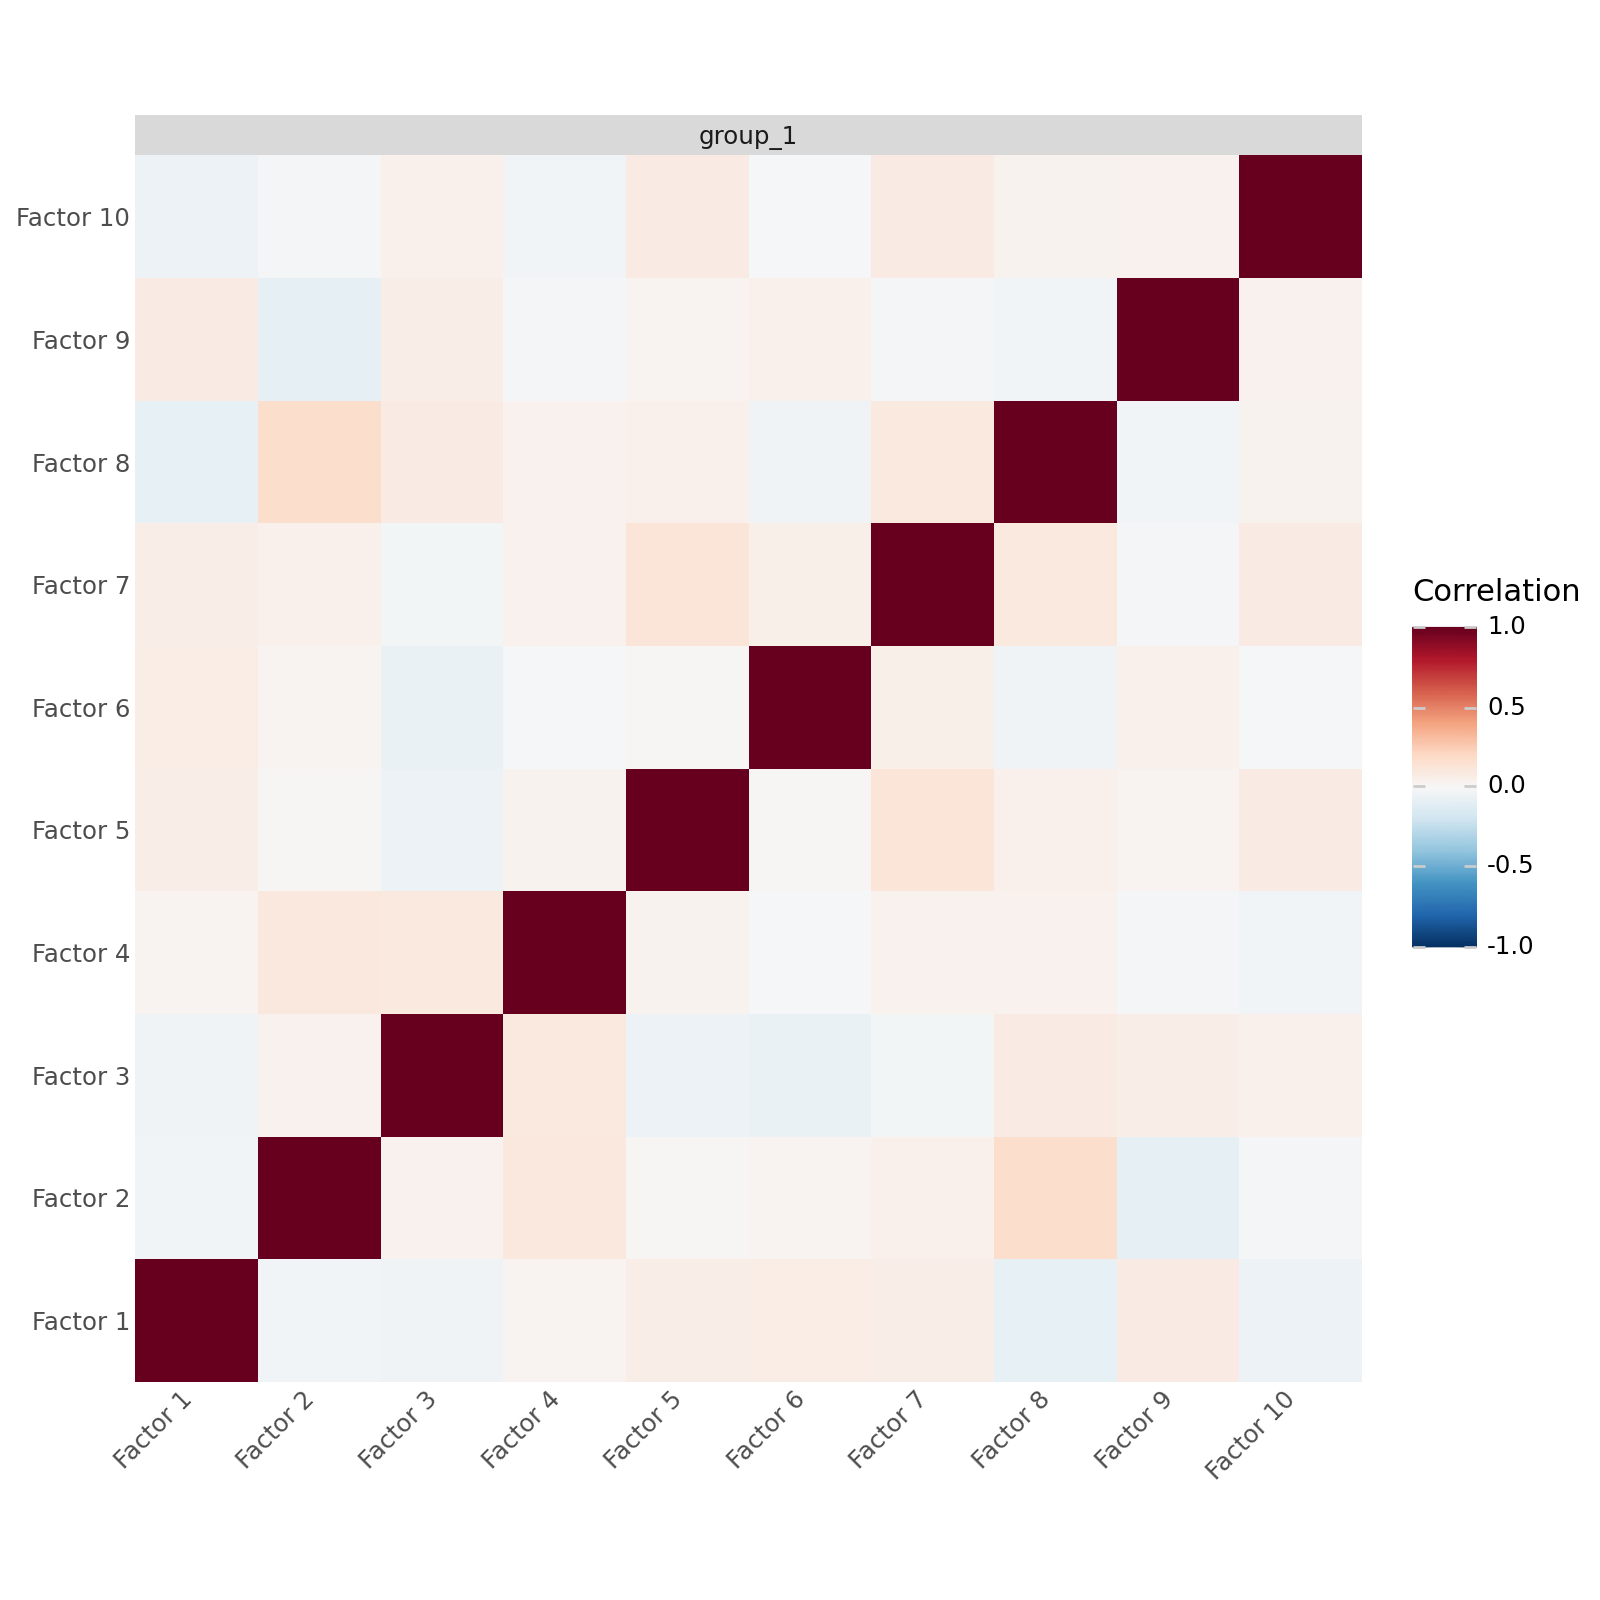

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 8 x 8 in image.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /g/stegle/aalsayah/repos/data/merfish/mouse_brain/mofa_models/evaluation_results2/variance_explained.png



Plotting variance explained...


/scratch/jobs/43257208/ipykernel_150798/1526382549.py:55: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


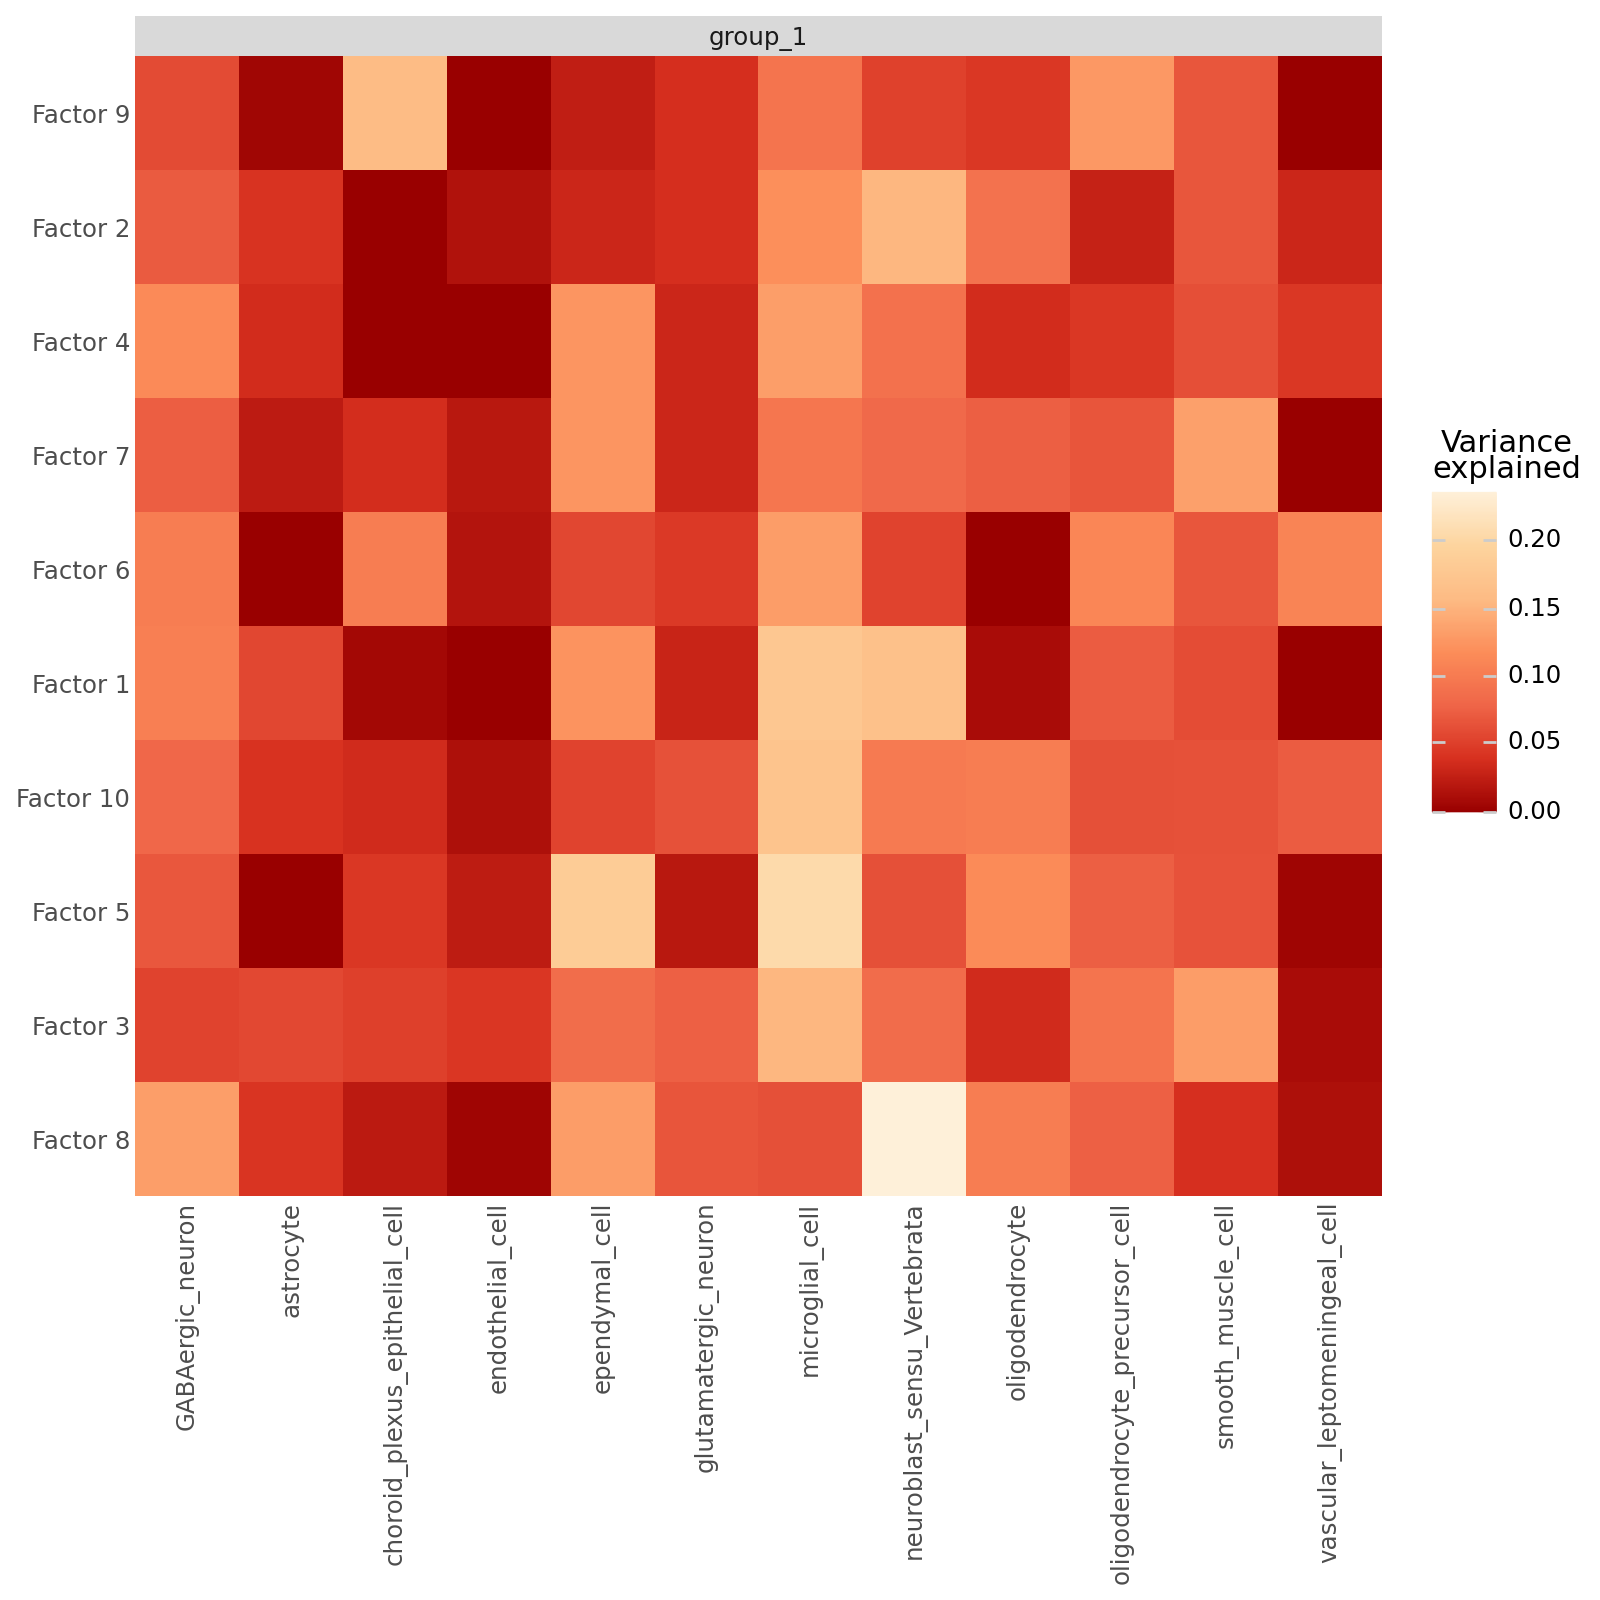


Computing R²...
✅ Mean R² for group_1: 0.7135


In [82]:
results = evaluate_single_mofa_model(model, output_dir="/g/stegle/aalsayah/repos/data/merfish/mouse_brain/mofa_models/evaluation_results2", group="group_1", show_plots=True)

# Link results to lrdata

In [2]:
merfish_path = Path("/g/stegle/aalsayah/repos/data/merfish/mouse_brain/lrdata")
lrdata = sc.read(merfish_path / "WB_MERFISH_animal2_coronal_lrdata.h5ad")

## 3.Weights dist

In [84]:
weights_dict= model.get_weights()

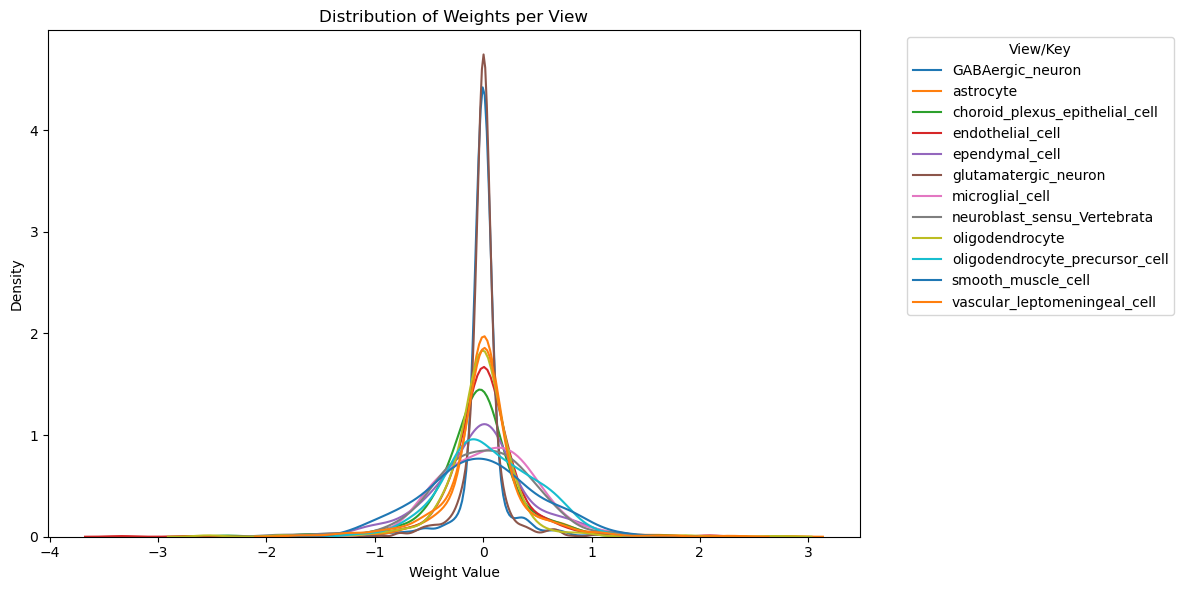

In [85]:
plt.figure(figsize=(12, 6))

# Loop through each view/key
for key, df in weights_dict.items():
    # Flatten all weights from that DataFrame into 1D array
    values = df.values.flatten()
    sns.kdeplot(values, label=key, fill=False)  # distribution curve

plt.title("Distribution of Weights per View")
plt.xlabel("Weight Value")
plt.ylabel("Density")
plt.legend(title="View/Key", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from tqdm.auto import tqdm

# Automated clustering sweep and metrics calculation
# Produces a DataFrame with cluster count and all metrics computed below
# Requires variables already present in the notebook: `factors`, `lrdata_clean2`,
# `StandardScaler`, `KMeans`, `silhouette_score`, `normalized_mutual_info_score`,
# `adjusted_mutual_info_score`, `homogeneity_score`, `adjusted_rand_score`,
# and `spatial_coherence_score`.


# choose cluster counts to evaluate
n_clusters_list = list(range(2, 13))  # change as needed

# align factors to the filtered AnnData (lrdata_clean2)
common_idx = factors.index.intersection(lrdata_clean2.obs_names)
factors_sub = factors.loc[common_idx].copy()

# remove columns that are not factor values
drop_cols = [c for c in ["cluster", "anno"] if c in factors_sub.columns]
X_f = factors_sub.drop(columns=drop_cols)

# standardize
X_std = StandardScaler().fit_transform(X_f.values)

# spatial coords aligned to same ordering
X_spatial = lrdata_clean2.obsm["X_spatial_coords"]
# ensure same ordering: lrdata_clean2.obs_names should equal common_idx order
if not (list(common_idx) == list(lrdata_clean2.obs_names)):
    # reorder spatial coords to match factors_sub
    X_spatial = lrdata_clean2.obsm["X_spatial_coords"][ [lrdata_clean2.obs_names.get_loc(i) for i in common_idx], : ]

results = []
for k in tqdm(n_clusters_list, desc="kmeans sweep"):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_std)

    # compute metrics (use lrdata_clean2 labels where appropriate)
    # silhouette on spatial coords using cluster labels
    try:
        sil_spatial = float(silhouette_score(X_spatial, labels))
    except Exception:
        sil_spatial = float("nan")

    # NMI
    nmi_celltype = float(normalized_mutual_info_score(lrdata_clean2.obs["cell_type"].astype(str).values, labels))
    nmi_region = float(normalized_mutual_info_score(lrdata_clean2.obs["major_brain_region"].astype(str).values, labels))

    # AMI
    ami_celltype = float(adjusted_mutual_info_score(lrdata_clean2.obs["cell_type"].astype(str).values, labels))
    ami_region = float(adjusted_mutual_info_score(lrdata_clean2.obs["major_brain_region"].astype(str).values, labels))

    # Homogeneity (true, pred)
    hom_celltype = float(homogeneity_score(lrdata_clean2.obs["cell_type"].astype(str).values, labels))
    hom_region = float(homogeneity_score(lrdata_clean2.obs["major_brain_region"].astype(str).values, labels))

    # ARI
    ari_celltype = float(adjusted_rand_score(lrdata_clean2.obs["cell_type"].astype(str).values, labels))
    ari_region = float(adjusted_rand_score(lrdata_clean2.obs["major_brain_region"].astype(str).values, labels))

    # Spatial coherence score (uses the notebook-defined function)
    try:
        scs = float(spatial_coherence_score(X_spatial, labels, k=5))
    except Exception:
        scs = float("nan")

    results.append({
        "n_clusters": k,
        "silhouette_spatial": sil_spatial,
        "nmi_cluster_cell_type": nmi_celltype,
        "nmi_cluster_major_brain_region": nmi_region,
        "ami_cluster_cell_type": ami_celltype,
        "ami_cluster_major_brain_region": ami_region,
        "hom_cluster_cell_type": hom_celltype,
        "hom_cluster_major_brain_region": hom_region,
        "ari_cluster_cell_type": ari_celltype,
        "ari_cluster_major_brain_region": ari_region,
        "spatial_coherence_score": scs
    })

results_df = pd.DataFrame(results).set_index("n_clusters")
results_df = results_df.sort_index()

# show results and optionally save
print(results_df)
results_df.to_csv("clustering_metrics_sweep.csv")

# Cluster factors

In [23]:
from sklearn.metrics import *
import pandas as pd
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors

In [24]:
factors = model.get_factors()
factors = factors["group_1"]

In [25]:
#lrdata_clean = lrdata[~lrdata.obs["cluster"].isna()].copy()
lrdata_clean = lrdata[~lrdata.obs["cell_type"].isna()].copy()
lrdata_clean = lrdata_clean[~lrdata_clean.obs["major_brain_region"].isna()].copy()

In [26]:
def spatial_coherence_score(X, labels, k=5):
    X = np.asarray(X)
    labels = np.asarray(labels)

    nbrs = NearestNeighbors(n_neighbors=k+1).fit(X)
    _, indices = nbrs.kneighbors(X)

    # exclude each point itself (indices[:,0])
    indices = indices[:, 1:]
    
    same_cluster_counts = np.sum(labels[indices] == labels[:, None], axis=1)
    scs = np.mean(same_cluster_counts / k)
    return scs


In [90]:
# choose cluster counts to evaluate
n_clusters_list = list(range(2, 20))  # change as needed

# align factors to the filtered AnnData (lrdata_clean2)
common_idx = factors.index.intersection(lrdata_clean.obs_names)
factors_sub = factors.loc[common_idx].copy()
lrdata_sub = lrdata_clean[common_idx, :].copy()

# remove columns that are not factor values
drop_cols = [c for c in ["cluster", "anno"] if c in factors_sub.columns]
X_f = factors_sub.drop(columns=drop_cols)

# standardize
X_std = StandardScaler().fit_transform(X_f.values)

# spatial coords aligned to same ordering
X_spatial = lrdata_sub.obsm["X_spatial_coords"]
# ensure same ordering: lrdata_clean.obs_names should equal common_idx order
if not (list(common_idx) == list(lrdata_sub.obs_names)):
    # reorder spatial coords to match factors_sub
    X_spatial = lrdata_sub.obsm["X_spatial_coords"][ [lrdata_sub.obs_names.get_loc(i) for i in common_idx], : ]

results = []
for k in tqdm(n_clusters_list, desc="kmeans sweep"):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_std)

    # compute metrics (use lrdata_clean labels where appropriate)
    # silhouette on spatial coords using cluster labels
    try:
        sil_spatial = float(silhouette_score(X_spatial, labels))
        sil_major_brain_region = float(silhouette_score(X_spatial, lrdata_sub.obs["major_brain_region"].astype(str).values))
    except Exception:
        sil_spatial = float("nan")

    # NMI
    nmi_celltype = float(normalized_mutual_info_score(lrdata_sub.obs["cell_type"].astype(str).values, labels))
    nmi_region = float(normalized_mutual_info_score(lrdata_sub.obs["major_brain_region"].astype(str).values, labels))
    nmi_ground_truth = float(normalized_mutual_info_score(lrdata_sub.obs["major_brain_region"].astype(str).values, lrdata_sub.obs["cell_type"].astype(str).values))

    # AMI
    ami_celltype = float(adjusted_mutual_info_score(lrdata_sub.obs["cell_type"].astype(str).values, labels))
    ami_region = float(adjusted_mutual_info_score(lrdata_sub.obs["major_brain_region"].astype(str).values, labels))
    ami_ground_truth = float(adjusted_mutual_info_score(lrdata_sub.obs["major_brain_region"].astype(str).values, lrdata_sub.obs["cell_type"].astype(str).values))

    # Homogeneity (true, pred)
    hom_celltype = float(homogeneity_score(lrdata_sub.obs["cell_type"].astype(str).values, labels))
    hom_region = float(homogeneity_score(lrdata_sub.obs["major_brain_region"].astype(str).values, labels))
    hom_ground_truth = float(homogeneity_score(lrdata_sub.obs["major_brain_region"].astype(str).values, lrdata_sub.obs["cell_type"].astype(str).values))

    # ARI
    ari_celltype = float(adjusted_rand_score(lrdata_sub.obs["cell_type"].astype(str).values, labels))
    ari_region = float(adjusted_rand_score(lrdata_sub.obs["major_brain_region"].astype(str).values, labels))
    ari_ground_truth = float(adjusted_rand_score(lrdata_sub.obs["major_brain_region"].astype(str).values, lrdata_sub.obs["cell_type"].astype(str).values))


    # Spatial coherence score (uses the notebook-defined function)
    try:
        scs = float(spatial_coherence_score(X_spatial, labels, k=3))
        scs_major_brain_region = float(spatial_coherence_score(X_spatial, lrdata_sub.obs["major_brain_region"].astype(str).values, k=3))
    except Exception:
        scs = float("nan")

    results.append({
        "n_clusters": k,
        "silhouette_spatial": sil_spatial,
        "silhouette_major_brain_region": sil_major_brain_region,
        "nmi_cluster_cell_type": nmi_celltype,
        "nmi_cluster_major_brain_region": nmi_region,
        "nmi_major_brain_region_vs_cell_type": nmi_ground_truth,
        "ami_cluster_cell_type": ami_celltype,
        "ami_cluster_major_brain_region": ami_region,
        "ami_major_brain_region_vs_cell_type": ami_ground_truth,
        "hom_cluster_cell_type": hom_celltype,
        "hom_cluster_major_brain_region": hom_region,
        "hom_major_brain_region_vs_cell_type": hom_ground_truth,
        "ari_cluster_cell_type": ari_celltype,
        "ari_cluster_major_brain_region": ari_region,
        "ari_major_brain_region_vs_cell_type": ari_ground_truth,
        "spatial_coherence_score": scs,
        "spatial_coherence_score_major_brain_region": scs_major_brain_region
    })

results_df = pd.DataFrame(results).set_index("n_clusters")
results_df = results_df.sort_index()

# show results and optionally save
print(results_df)
#results_df.to_csv("clustering_metrics_sweep.csv")

kmeans sweep:   0%|          | 0/18 [00:00<?, ?it/s]

            silhouette_spatial  silhouette_major_brain_region  \
n_clusters                                                      
2                    -0.055928                       0.008107   
3                    -0.060429                       0.008107   
4                    -0.095051                       0.008107   
5                    -0.110390                       0.008107   
6                    -0.118792                       0.008107   
7                    -0.136949                       0.008107   
8                    -0.147694                       0.008107   
9                    -0.170787                       0.008107   
10                   -0.166882                       0.008107   
11                   -0.180547                       0.008107   
12                   -0.240332                       0.008107   
13                   -0.263406                       0.008107   
14                   -0.307339                       0.008107   
15                   -0.3

In [42]:
# Standardize the data
X = StandardScaler().fit_transform(factors)

# Cluster into 6 groups
kmeans = KMeans(n_clusters=10, random_state=42)
factors['cluster'] = kmeans.fit_predict(X)

# Inspect results
print(factors.groupby('cluster').mean())

         Factor 1  Factor 2  Factor 3  Factor 4  Factor 5  Factor 6  Factor 7  \
cluster                                                                         
0       -1.040888  0.491629  0.660446  0.548478  0.498867  0.697087 -1.209651   
1       -0.490796  1.046040 -0.503199 -0.628228 -1.212609  0.202946 -0.995911   
2        0.127503 -0.064159 -0.263548  0.332851 -0.023958  0.087318  0.210372   
3        0.468016 -0.573176  1.236693 -0.669328 -0.557254  1.587178  0.537108   
4        1.428934  0.986000  0.928177  0.726193  1.325275 -0.761722 -0.028416   
5       -0.382090  0.300295  0.636027  0.174676 -0.319764 -0.689471 -0.113584   
6        0.821459 -1.308816  0.582425  0.220935  0.872058 -0.756351 -0.635752   
7        0.453698 -0.933523 -0.243640 -0.574504 -0.150265 -0.285762 -0.705481   
8       -0.163629  0.092729 -0.027015  0.456683  0.043575  0.191496  0.680908   
9       -0.242597  0.180476 -1.778168 -1.451121  1.538853  0.345514  0.739305   

         Factor 8  Factor 9

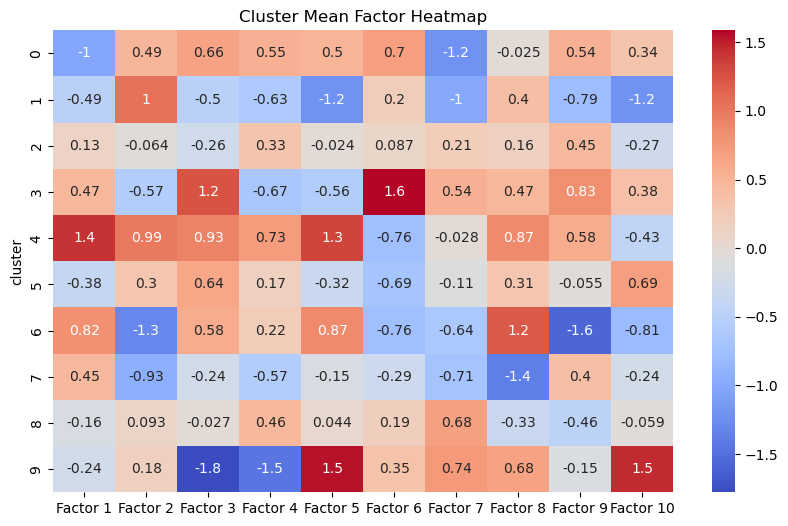

In [44]:
df = factors.groupby('cluster').mean()

plt.figure(figsize=(10,6))
sns.heatmap(df, annot=True, cmap='coolwarm')  # annot=True adds values
plt.title("Cluster Mean Factor Heatmap")
plt.show()

In [45]:
lrdata.obs["cluster"] = factors["cluster"].astype("category")

In [46]:
lrdata_clean = lrdata[~lrdata.obs["cluster"].isna()].copy()
lrdata_clean2 = lrdata_clean[~lrdata_clean.obs["cell_type"].isna()].copy()
lrdata_clean2 = lrdata_clean2[~lrdata_clean2.obs["major_brain_region"].isna()].copy()

# Spatial accuracy benchmark


In [63]:
from scipy.spatial import *
from sklearn.preprocessing import *

from sklearn.metrics import *
from scipy.spatial.distance import *

In [ ]:
lrdata.obs["cluster"] = factors["cluster"].astype("category")

ASW: Silhouette score of all data points, which quantifies how well clusters are separated

Drop NA


In [114]:
lrdata_clean = lrdata[~lrdata.obs["cluster"].isna()].copy()
lrdata_clean2 = lrdata_clean[~lrdata_clean.obs["cell_type"].isna()].copy()
lrdata_clean2 = lrdata_clean2[~lrdata_clean2.obs["major_brain_region"].isna()].copy()

## ASW


In [115]:
asw = silhouette_score(lrdata_clean2.obsm["X_spatial_coords"], lrdata_clean2.obs["major_brain_region"])

print("Average Silhouette Width:", asw)

Average Silhouette Width: 0.008106770851235642


In [116]:
asw = silhouette_score(lrdata_clean2.obsm["X_spatial_coords"], lrdata_clean2.obs["cell_type"])

print("Average Silhouette Width:", asw)

Average Silhouette Width: -0.5314861265461052


In [117]:
asw = silhouette_score(lrdata_clean2.obsm["X_spatial_coords"], lrdata_clean2.obs["cluster"])

print("Average Silhouette Width:", asw)

Average Silhouette Width: -0.10892229250498917


## NMI

In [80]:
normalized_mutual_info_score(lrdata_clean2.obs["cell_type"],lrdata_clean2.obs["cluster"])

np.float64(0.10461829268652743)

In [97]:
normalized_mutual_info_score(lrdata_clean2.obs["cell_type"],lrdata_clean2.obs["major_brain_region"])

np.float64(0.13686570435734666)

In [98]:
normalized_mutual_info_score(lrdata_clean2.obs["cluster"],lrdata_clean2.obs["major_brain_region"])

np.float64(0.07519263702195289)

## AMI

In [100]:
ami = adjusted_mutual_info_score(lrdata_clean2.obs["cell_type"], lrdata_clean2.obs["cluster"])
print("Adjusted Mutual Information:", ami)

Adjusted Mutual Information: 0.10316340776405553


In [101]:

ami = adjusted_mutual_info_score(lrdata_clean2.obs["major_brain_region"], lrdata_clean2.obs["cluster"])
print("Adjusted Mutual Information:", ami)

Adjusted Mutual Information: 0.0742726163762381


In [102]:

ami = adjusted_mutual_info_score(lrdata_clean2.obs["major_brain_region"], lrdata_clean2.obs["cell_type"])
print("Adjusted Mutual Information:", ami)

Adjusted Mutual Information: 0.13336746947531514


## HOM

In [ ]:
hom = homogeneity_score(lrdata_clean2.obs["major_brain_region"], lrdata_clean2.obs["cell_type"])
print("Homogeneity:", hom)


Homogeneity: 0.11711602426317236


In [105]:
hom = homogeneity_score(lrdata_clean2.obs["major_brain_region"], lrdata_clean2.obs["cluster"])
print("Homogeneity:", hom)


Homogeneity: 0.06752448508716911


In [106]:
hom = homogeneity_score(lrdata_clean2.obs["cell_type"], lrdata_clean2.obs["cluster"])
print("Homogeneity:", hom)

Homogeneity: 0.11164036625087366


## ARI

In [87]:
adjusted_rand_score(lrdata_clean.obs["cell_type"],lrdata_clean.obs["cluster"])

0.1017284618282303

In [96]:
adjusted_rand_score(lrdata_clean2.obs["major_brain_region"],lrdata_clean2.obs["cluster"])

0.037150644065342235

In [95]:
adjusted_rand_score(lrdata_clean2.obs["major_brain_region"],lrdata_clean2.obs["cell_type"])

0.18303120777750512

## SCS

In [ ]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

def spatial_coherence_score(X, labels, k=5):
    X = np.asarray(X)
    labels = np.asarray(labels)

    nbrs = NearestNeighbors(n_neighbors=k+1).fit(X)
    _, indices = nbrs.kneighbors(X)

    # exclude each point itself (indices[:,0])
    indices = indices[:, 1:]
    
    same_cluster_counts = np.sum(labels[indices] == labels[:, None], axis=1)
    scs = np.mean(same_cluster_counts / k)
    return scs


In [122]:
print("Spatial Coherence Score:", spatial_coherence_score(lrdata_clean2.obsm["X_spatial_coords"], lrdata_clean2.obs["major_brain_region"], k=5))

Spatial Coherence Score: 0.9656665530173884


In [123]:
print("Spatial Coherence Score:", spatial_coherence_score(lrdata_clean2.obsm["X_spatial_coords"], lrdata_clean2.obs["cell_type"], k=5))

Spatial Coherence Score: 0.5975622229798842


In [ ]:
print("Spatial Coherence Score:", spatial_coherence_score(lrdata_clean2.obsm["X_spatial_coords"], lrdata_clean2.obs["cluster"], k=5))

Spatial Coherence Score: 0.4702523013978861


# Regression Model

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [74]:
obskey1 = lrdata.obs["major_brain_region"]
factors['anno'] = obskey1.reindex(factors.index)
factors = factors.dropna()
print(factors['anno'].isna().sum())
len(factors)

0


11732

In [75]:
X = factors.drop(columns=['cluster', 'anno']).values
X

array([[ 0.74493825, -0.15249473,  0.7332811 , ...,  1.1311829 ,
        -1.5504568 ,  0.22859158],
       [ 0.12534921,  0.9525114 ,  1.5767106 , ..., -2.113156  ,
        -0.735865  ,  0.85337496],
       [-1.2228318 ,  0.58464575,  1.009487  , ..., -0.27983132,
         0.56641245, -1.134998  ],
       ...,
       [-1.8437614 ,  0.4912646 ,  1.2410282 , ...,  0.50232464,
         2.0473814 ,  0.40781668],
       [-1.3468814 ,  0.01271958, -0.00483806, ...,  1.1304531 ,
         1.0523702 , -0.55002934],
       [-3.112668  , -0.6771402 ,  0.29666898, ...,  1.5174205 ,
         1.2321439 ,  0.9997811 ]], shape=(11732, 10), dtype=float32)

In [76]:
anno = factors["anno"].values
anno

['Olfactory', 'Ventricular_systems', 'Fiber_tracts', 'Fiber_tracts', 'Ventricular_systems', ..., 'Thalamus', 'Ventricular_systems', 'Ventricular_systems', 'Ventricular_systems', 'Isocortex']
Length: 11732
Categories (10, object): ['Cortical_subplate', 'Fiber_tracts', 'Hippocampus', 'Hypothalamus', ..., 'Pallidum', 'Striatum', 'Thalamus', 'Ventricular_systems']

### Create X and Y objects

### Train multinomial logistic regression

In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
   X, anno, test_size=0.3, random_state=42, stratify=anno
)

In [78]:
clf = LogisticRegression(
    solver="lbfgs",
    max_iter=200,
    class_weight="balanced"
)

In [79]:
clf.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=200)

### Evaluate the model

In [53]:
# Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.34005681818181815

Classification Report:
                      precision    recall  f1-score   support

  Cortical_subplate       0.24      0.37      0.29       213
       Fiber_tracts       0.10      0.33      0.16       110
        Hippocampus       0.02      0.50      0.03         6
       Hypothalamus       0.37      0.32      0.34       430
          Isocortex       0.68      0.39      0.49      1318
          Olfactory       0.24      0.36      0.29       264
           Pallidum       0.02      0.15      0.03        27
           Striatum       0.50      0.26      0.34       768
           Thalamus       0.42      0.37      0.39       352
Ventricular_systems       0.02      0.09      0.03        32

           accuracy                           0.34      3520
          macro avg       0.26      0.31      0.24      3520
       weighted avg       0.49      0.34      0.39      3520



### AUC

In [54]:
from sklearn.metrics import roc_auc_score, roc_curve

#### 1. If threr are 2 classes only (healthy vs. disease)

In [ ]:
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Calculate AUC
auc = roc_auc_score(y_test, y_pred_proba)
print("AUC:", auc)


fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label="222_REF")
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#### 2. If classes are more than 2:

In [55]:
# Get class probabilities 
y_proba = clf.predict_proba(X_test)  

# Compute macro-average AUC (each class equally weighted)
auc_macro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
print(f"Multiclass ROC AUC (OvR, macro): {auc_macro:.4f}")

# weights by class support:
auc_weighted = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
print(f"Multiclass ROC AUC (OvR, weighted): {auc_weighted:.4f}")


Multiclass ROC AUC (OvR, macro): 0.7457
Multiclass ROC AUC (OvR, weighted): 0.7375


# Local Indicators of Spatial Association (LISA)

In [31]:
import geopandas as gpd
import libpysal as lps
from esda.moran import Moran_Local
import numpy as np
from esda.join_counts import Join_Counts
from scipy.sparse import csr_matrix

In [32]:
coords = lrdata.obsm["X_spatial_coords"]

In [33]:
coords

array([[ 46325.96807155, -21043.99777831],
       [ 46322.02849143, -21020.19527093],
       [ 46323.88916434, -21053.17742423],
       ...,
       [ 51412.97162662, -21404.44123572],
       [ 51430.25151795, -21574.45726556],
       [ 51425.54356365, -21805.0640525 ]], shape=(49111, 2))

In [47]:
lrdata.obs["cluster"].value_counts()

cluster
8    2368
2    2302
5    2109
7    1617
1     838
9     632
0     607
3     605
4     437
6     386
Name: count, dtype: int64

In [48]:
regions = lrdata.obs["cluster"]

In [49]:
valid = ~pd.isna(regions)
coords_clean = coords[valid]
regions_clean = np.array(regions)[valid]

In [50]:
from libpysal.weights import DistanceBand
import esda

# build distance neighbors (choose threshold based on tissue scale)
w = DistanceBand(coords_clean, threshold=30, binary=True)  # ~30 microns example

unique_regions = np.unique(regions_clean)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/libpysal/weights/util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 3023 disconnected components.
 There are 1564 islands with ids: 0, 3, 9, 13, 16, 20, 31, 73, 77, 100, 101, 103, 111, 112, 131, 140, 144, 162, 170, 174, 177, 188, 198, 218, 241, 255, 259, 265, 269, 271, 274, 284, 285, 286, 288, 289, 293, 294, 295, 296, 299, 300, 305, 308, 309, 320, 337, 358, 359, 360, 361, 362, 377, 388, 425, 426, 444, 446, 454, 488, 489, 492, 495, 498, 502, 505, 506, 509, 512, 514, 516, 517, 519, 520, 528, 534, 541, 543, 547, 548, 550, 555, 562, 571, 581, 602, 603, 609, 613, 617, 620, 661, 705, 706, 707, 709, 711, 732, 735, 750, 755, 756, 780, 790, 800, 815, 824, 825, 828, 837, 862, 870, 874, 880, 885, 890, 894, 895, 897, 906, 912, 913, 915, 919, 922, 934, 940, 951, 973, 976, 978, 983, 984, 985, 1007, 1009, 1010, 1014, 1021, 1022, 1023, 1027, 1032, 1040, 1043, 1064, 1073, 1076, 1112, 1113, 1119, 1168

In [16]:
results = []

for r in unique_regions:
    y = (regions_clean == r).astype(int)  # one-vs-rest binary mask
    jc = esda.join_counts.Join_Counts(y, w)
    
    results.append({
        "region": r,
        "BB": jc.bb,            # region with region
        "WW": jc.ww,            # other with other
        "BW": jc.bw,            # mixing
        "expected_BB": jc.mean_bb,
        "p_value": jc.p_sim_bb
    })

# convert to DataFrame for display
import pandas as pd
df = pd.DataFrame(results)
print(df.sort_values("p_value"))

                region       BB        WW      BW   expected_BB  p_value
0    Cortical_subplate   4743.0  150191.0   475.0    197.495495    0.001
1         Fiber_tracts  14252.0  138556.0  2601.0   1671.413413    0.001
2          Hippocampus   3726.0  151273.0   410.0     81.925926    0.001
3         Hypothalamus  16725.0  137886.0   798.0   1704.985986    0.001
4            Isocortex  48418.0  106425.0   566.0  16471.981982    0.001
5            Olfactory   8067.0  147042.0   300.0    605.815816    0.001
6             Pallidum   3874.0  151135.0   400.0    175.777778    0.001
7             Striatum  23842.0  130310.0  1257.0   3647.793794    0.001
8             Thalamus  15994.0  138383.0  1032.0   2199.442442    0.001
9  Ventricular_systems  11257.0  142969.0  1183.0    239.301301    0.001


In [51]:
results = []

for r in unique_regions:
    y = (regions_clean == r).astype(int)  # one-vs-rest binary mask
    jc = esda.join_counts.Join_Counts(y, w)
    
    results.append({
        "region": r,
        "BB": jc.bb,            # region with region
        "WW": jc.ww,            # other with other
        "BW": jc.bw,            # mixing
        "expected_BB": jc.mean_bb,
        "p_value": jc.p_sim_bb
    })

# convert to DataFrame for display
import pandas as pd
df = pd.DataFrame(results)
print(df.sort_values("p_value"))

   region      BB       WW      BW  expected_BB  p_value
0     0.0   183.0  14207.0  1235.0    40.495495    0.001
1     1.0   680.0  12927.0  2018.0    77.460460    0.001
2     2.0   809.0  11458.0  3358.0   584.452452    0.001
3     3.0   128.0  14131.0  1366.0    40.227227    0.001
4     4.0   139.0  14597.0   889.0    21.103103    0.001
5     5.0  1268.0  10927.0  3430.0   490.168168    0.001
6     6.0    53.0  14694.0   878.0    16.519520    0.001
8     8.0  1235.0  10693.0  3697.0   618.995996    0.001
9     9.0    44.0  14167.0  1414.0    44.307307    0.538
7     7.0   270.0  12008.0  3347.0   288.104104    0.852


/scratch/jobs/43257208/ipykernel_268633/4191766863.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


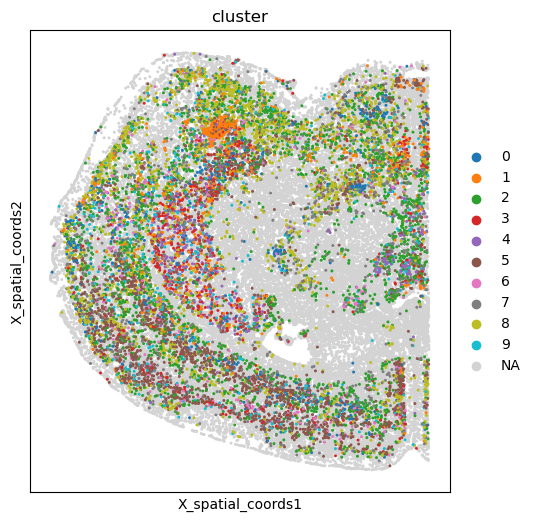

<Figure size 640x480 with 0 Axes>

In [52]:
fig, axes = plt.subplots(1, 1, figsize=(6, 6))
sc.pl.spatial(
    lrdata,
    color='cluster',
    spot_size=40,
    ax=axes,
    basis="X_spatial_coords"
)
plt.tight_layout()